# Titanic Machine Learning Project

**Goal:** Predict whether a Titanic passenger survived.

## 1. Imports

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant




## 2. Load the Data

In [78]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

print("Training data shape:", train_df.shape)
print("Testing data shape:", test_df.shape)

Training data shape: (891, 12)
Testing data shape: (418, 11)


## 3. Exploratory Data Analysis - Training Data

In [79]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [80]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [81]:
train_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [82]:
train_df.describe(include=['O'])


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,4,644


In [83]:
train_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## 4. Exploratory Data Analysis - Test Data

In [84]:
test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [85]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [86]:
test_df.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [87]:
test_df.describe(include=['O'])


,Name,Sex,Ticket,Cabin,Embarked
count,418,418,418,91,418
unique,418,2,363,76,3
top,"Kelly, Mr. James",male,PC 17608,B57 B59 B63 B66,S
freq,1,266,5,3,270


In [88]:
test_df.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

## 5 Visualize the Raw Data

Look at the distribution before cleaning so we're seeing the real, unimputed data

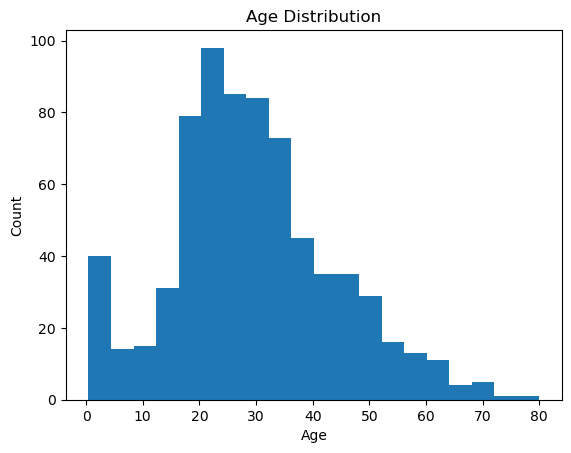

In [89]:
plt.hist(train_df['Age'], bins =20)
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age Distribution')
plt.show()

## 5a. Survival Rate by Sex

In [90]:
train_df.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

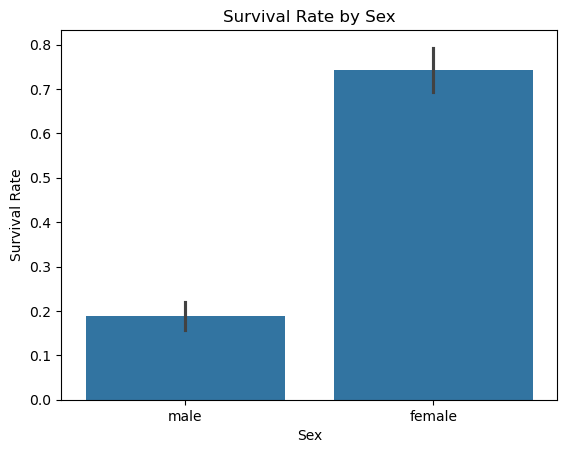

In [91]:
sns.barplot(data=train_df, x='Sex', y='Survived')
plt.ylabel('Survival Rate')
plt.title('Survival Rate by Sex')
plt.show()

## 5b. Survival Rate by Pclass

In [92]:
train_df.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

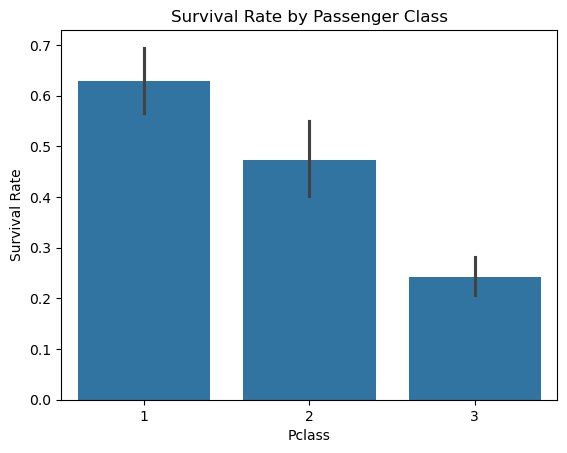

In [93]:
sns.barplot(data=train_df, x='Pclass', y='Survived')
plt.ylabel('Survival Rate')
plt.title('Survival Rate by Passenger Class')
plt.show()

## 5c. Survival Rate by Cabin Deck

Cabin is mostly missing (687/891), so we can't use raw values directly. As a first look, we extract the deck letter (first character of Cabin) and treat missing cabins as their own group `'Unknown'` — this lets us see whether *having a recorded cabin at all* relates to survival, without permanently altering `train_df` yet (that decision happens later, in Cleaning).

In [94]:
cabin_deck = train_df['Cabin'].str[0].fillna('Unknown')

train_df.assign(Deck=cabin_deck).groupby('Deck')['Survived'].mean()

Deck
A          0.466667
B          0.744681
C          0.593220
D          0.757576
E          0.750000
F          0.615385
G          0.500000
T          0.000000
Unknown    0.299854
Name: Survived, dtype: float64

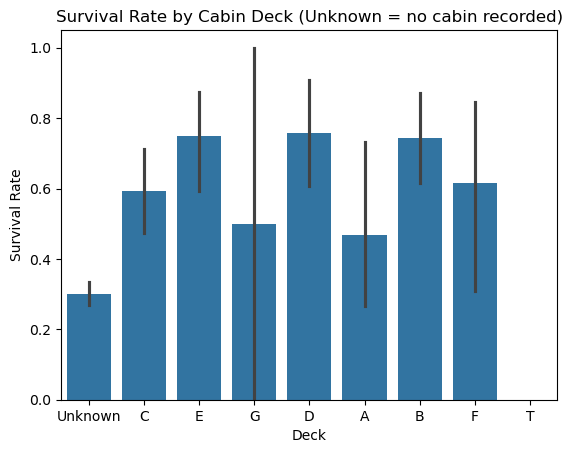

In [95]:
sns.barplot(x=cabin_deck, y=train_df['Survived'])
plt.xlabel('Deck')
plt.ylabel('Survival Rate')
plt.title('Survival Rate by Cabin Deck (Unknown = no cabin recorded)')
plt.show()

## 5d. Survival Rate by Family Size

Combining `SibSp` (siblings/spouses aboard) and `Parch` (parents/children aboard) into a single `Family_Size` column: `SibSp + Parch + 1` (the `+1` counts the passenger themselves). Created in both `train_df` and `test_df` now, since this will likely become an actual model feature later.

In [96]:
train_df['Family_Size'] = train_df['SibSp'] + train_df['Parch'] + 1
test_df['Family_Size'] = test_df['SibSp'] + test_df['Parch'] + 1

train_df.groupby('Family_Size')['Survived'].mean()

Family_Size
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64

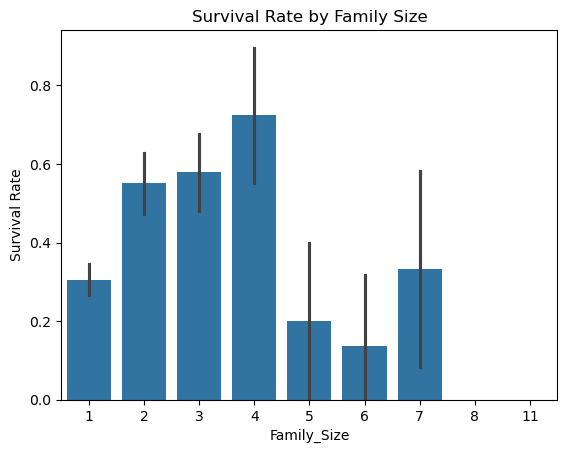

In [97]:
sns.barplot(data=train_df, x='Family_Size', y='Survived')
plt.ylabel('Survival Rate')
plt.title('Survival Rate by Family Size')
plt.show()

## 5e. Age Distribution by Survival

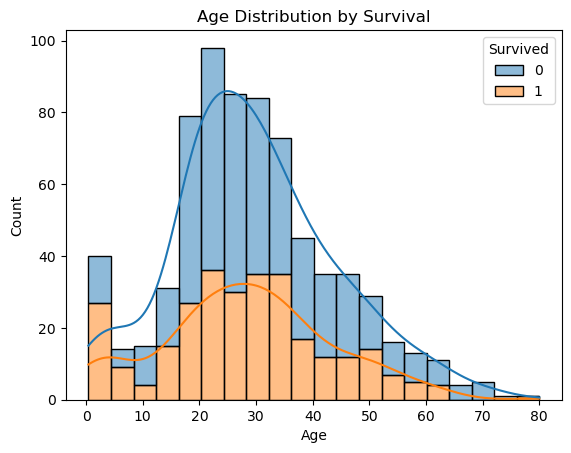

In [98]:
sns.histplot(data=train_df, x='Age', hue='Survived', bins=20, kde=True, multiple='stack')
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age Distribution by Survival')
plt.show()

## 5f. Fare Distribution by Survival

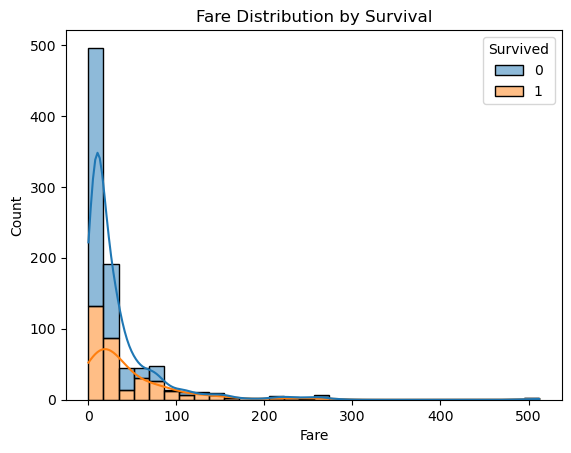

In [99]:
sns.histplot(data=train_df, x='Fare', hue='Survived', bins=30, kde=True, multiple='stack')
plt.xlabel('Fare')
plt.ylabel('Count')
plt.title('Fare Distribution by Survival')
plt.show()

## 5g. Survival Rate by Embarked

In [100]:
train_df.groupby('Embarked')['Survived'].mean()

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64

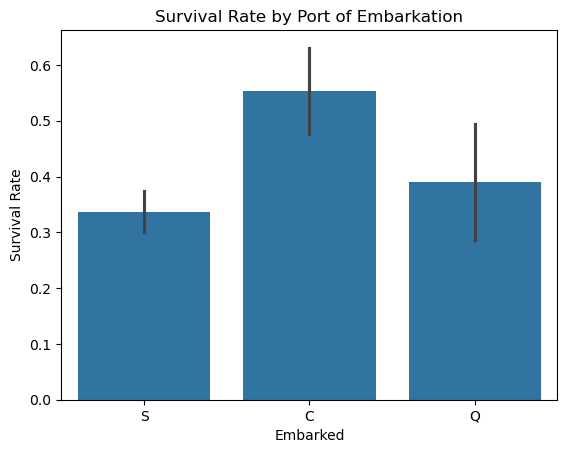

In [101]:
sns.barplot(data=train_df, x='Embarked', y='Survived')
plt.ylabel('Survival Rate')
plt.title('Survival Rate by Port of Embarkation')
plt.show()

## 5h. Survival Rate by Title

In [102]:
title = train_df['Name'].str.extract(r',\s*([^.]*)\.', expand=False).str.strip()

train_df.assign(Title=title).groupby('Title')['Survived'].agg(['count', 'mean']).sort_values('count', ascending=False)

,count,mean
Title,,
Mr,517,0.156673
Miss,182,0.697802
Mrs,125,0.792000
Master,40,0.575000
Dr,7,0.428571
Rev,6,0.000000
Major,2,0.500000
Col,2,0.500000
Mlle,2,1.000000


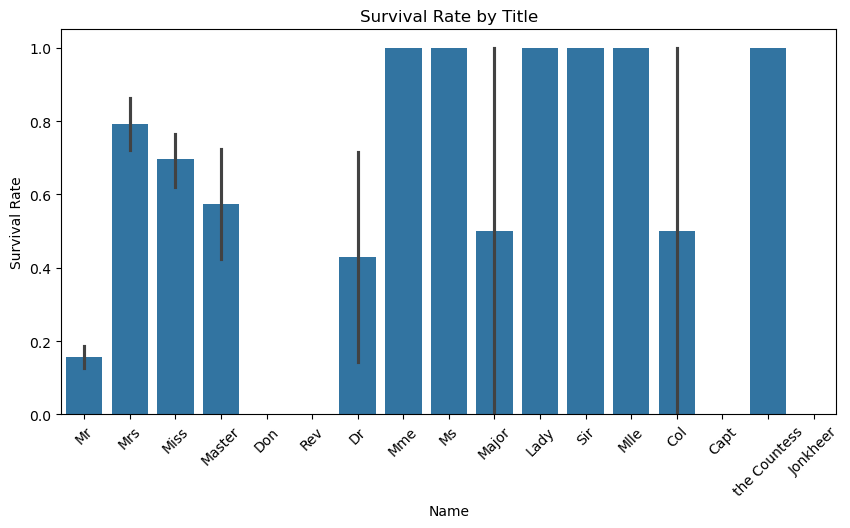

In [103]:
plt.figure(figsize=(10, 5))
sns.barplot(x=title, y=train_df['Survived'])
plt.ylabel('Survival Rate')
plt.title('Survival Rate by Title')
plt.xticks(rotation=45)
plt.show()

## 5i. Correlation Heatmap

A single summary view across numeric columns - a gut-check before modeling for which features correlate most strongly with Survived, and whether any features are strongly correlated with each other.

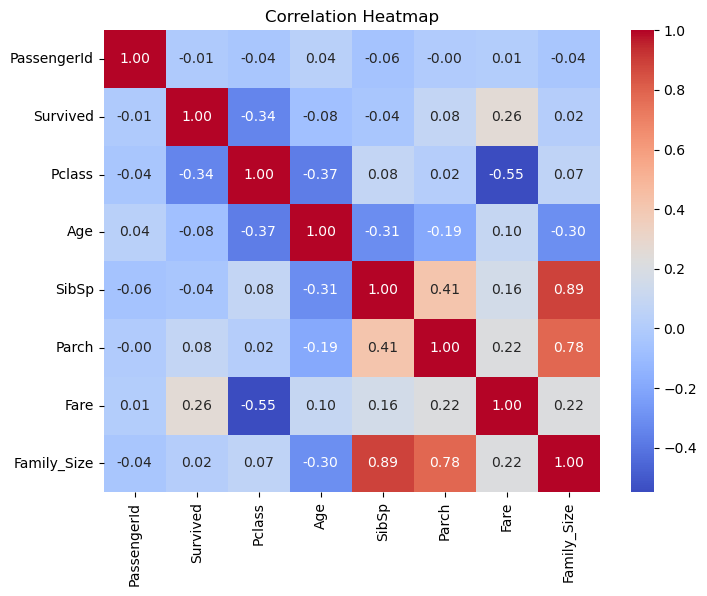

In [104]:
plt.figure(figsize=(8, 6))
sns.heatmap(train_df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## 5j. Outlier Detection - Boxplots

Checking the two continuous columns, Age, and Fare, for extreme values using boxplots and the IQR rule. This is the same logic from linear regression influence diagnostics - the goal here is just to see what's out there before deciding whether anything needs to be addressed. 

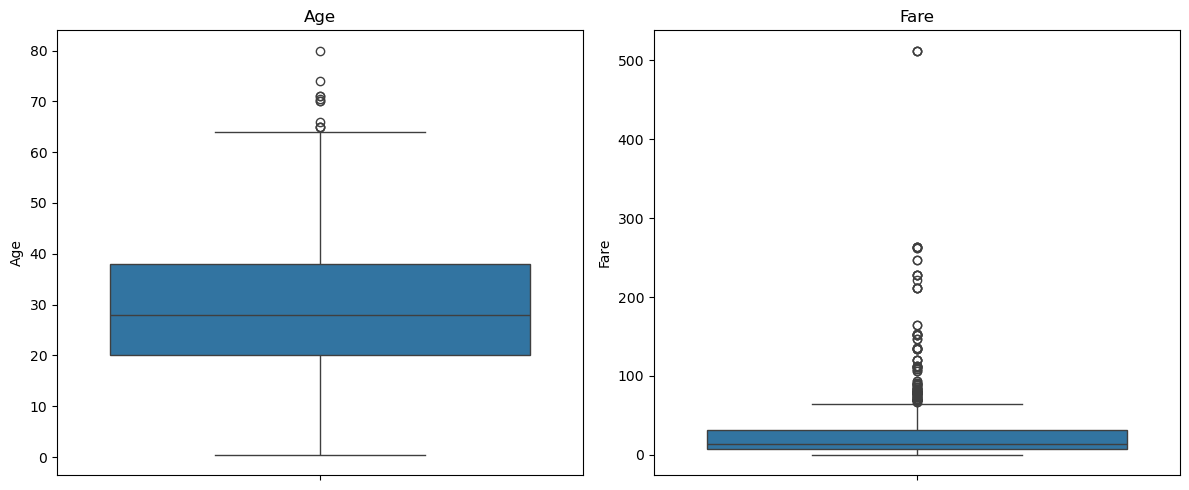

In [105]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.boxplot(y=train_df['Age'], ax=axes[0])
axes[0].set_title('Age')

sns.boxplot(y=train_df['Fare'], ax=axes[1])
axes[1].set_title('Fare')

plt.tight_layout()
plt.show()

In [106]:
def iqr_outlier_count(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = series[(series < lower) | (series > upper)]
    return(len(outliers), lower, upper)

for col in ['Age', 'Fare']:
    count, lower, upper = iqr_outlier_count(train_df[col])
    print(f"{col}: {count} outliers outside [{lower:.2f}, {upper:.2f}]")

Age: 11 outliers outside [-6.69, 64.81]
Fare: 116 outliers outside [-26.72, 65.63]


## 6. Data Cleaning

Missing values found above:
- **Age**: 177 missing (train) — numeric, meaningful predictor → impute
- **Fare**: 1 missing (test only) — numeric → impute
- **Embarked**: 2 missing (train only) — categorical, tiny amount → drop rows
- **Cabin**: 687 missing (train), majority missing (test) — too sparse to impute reliably → drop column

**Rule followed throughout:** any statistic used to fill values (mean, etc.) is computed from `train_df` only, then applied to both `train_df` and `test_df`, to avoid leaking test information into the cleaning step.

## 6a. Age - Impute with train mean

In [107]:
age_mean = train_df['Age'].mean()
train_df['Age'] = train_df['Age'].fillna(age_mean)
test_df['Age'] = test_df['Age'].fillna(age_mean)

## 6b. Fare - impute with train mean (test only, since train has no gaps)

In [108]:
fare_mean = train_df['Fare'].mean()

test_df['Fare'] = test_df['Fare'].fillna(fare_mean)

## 6c. Embarked - drop the 2 missing rows (train only)


In [109]:
train_df = train_df.dropna(subset='Embarked')

### 6d. Cabin — extract a `Cabin_Assigned` flag, then drop the raw column

EDA showed a big survival gap based on whether a cabin was recorded at all (66.7% vs. 30.0%), much more stable than looking at individual deck letters (many of which had only a handful of passengers). We keep that signal as a binary flag, then drop the raw `Cabin` column since the text itself isn't usable directly.

In [110]:
train_df['Cabin_Assigned'] = train_df['Cabin'].notna().astype(int)
test_df['Cabin_Assigned'] = test_df['Cabin'].notna().astype(int)

train_df = train_df.drop('Cabin', axis=1)
test_df = test_df.drop('Cabin', axis=1)

## 6e. Title - extract from Name, group rare titles together

`Master` (young boys, 57.5% survival) behaves very differently from `Mr` (adult men, 15.7% survival) despite both being `Sex = male` — Title captures that distinction. Many titles only have 1-2 passengers (e.g. `Capt`, `Don`, `Jonkheer`), which isn't a reliable sample on its own, so we bucket the rare ones together the same way the reference script did: military ranks, nobility, and unmarried-female titles.

In [111]:
train_df['Title'] = train_df['Name'].str.extract(r',\s*([^.]*)\.', expand=False).str.strip()
test_df['Title'] = test_df['Name'].str.extract(r',\s*([^.]*)\.', expand=False).str.strip()

title_map = {
    'Capt': 'Military', 'Col': 'Military', 'Major': 'Military',
    'Jonkheer': 'Noble', 'the Countess': 'Noble', 'Don': 'Noble', 'Dona': 'Noble',
    'Lady': 'Noble', 'Sir': 'Noble',
    'Mlle': 'Unmarried Female', 'Ms': 'Unmarried Female', 'Mme': 'Unmarried Female'
}

train_df['Title'] = train_df['Title'].replace(title_map)
test_df['Title'] = test_df['Title'].replace(title_map)

train_df.groupby('Title')['Survived'].agg(['count', 'mean']).sort_values('count', ascending=False)

,count,mean
Title,,
Mr,517,0.156673
Miss,181,0.696133
Mrs,124,0.790323
Master,40,0.575000
Dr,7,0.428571
Rev,6,0.000000
Military,5,0.400000
Noble,5,0.600000
Unmarried Female,4,1.000000


## 6f. Drop Name and Ticket

Both are unstructured text we've already extracted what we need from (Title came from Name). Neither is usable by the models we're planning on using in raw form, so we drop them from both dataframes.

In [112]:
train_df = train_df.drop(['Name', 'Ticket'], axis=1)
test_df = test_df.drop(['Name', 'Ticket'], axis=1)

## 6g. Encode Sex, Embarked and Title

None of these three have a natural order, so each gets split into 0/1 columns instead of a single ranked number.

We combine train and test **only** to guarantee both end up with identical dummy columns (e.g. if a rare title only appeared in one of the two sets, encoding them separately could create mismatched columns). This is not the same risk as the Age/Fare mean earlier — we aren't computing any statistic from the combined data, just using it to line up category labels. `Survived` stays untouched by this.

In [113]:
train_df['is_train'] = 1
test_df['is_train'] = 0

combined = pd.concat([train_df, test_df], sort=False)
combined = pd.get_dummies(combined, columns=['Sex', 'Embarked', 'Title'], drop_first=True)

train_df = combined[combined['is_train'] == 1].drop('is_train', axis=1)
test_df = combined[combined['is_train'] == 0].drop(['is_train', 'Survived'], axis=1)

train_df.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Family_Size,Cabin_Assigned,Sex_male,Embarked_Q,Embarked_S,Title_Master,Title_Military,Title_Miss,Title_Mr,Title_Mrs,Title_Noble,Title_Rev,Title_Unmarried Female
0,1,0.0,3,22.0,1,0,7.2500,2,0,True,False,True,False,False,False,True,False,False,False,False
1,2,1.0,1,38.0,1,0,71.2833,2,1,False,False,False,False,False,False,False,True,False,False,False
2,3,1.0,3,26.0,0,0,7.9250,1,0,False,False,True,False,False,True,False,False,False,False,False
3,4,1.0,1,35.0,1,0,53.1000,2,1,False,False,True,False,False,False,False,True,False,False,False
4,5,0.0,3,35.0,0,0,8.0500,1,0,True,False,True,False,False,False,True,False,False,False,False


## 7. Verify Cleaning

In [114]:
print("Train nulls:")
print(train_df.isnull().sum())
print()
print("Test nulls:")
print(test_df.isnull().sum())

Train nulls:
PassengerId               0
Survived                  0
Pclass                    0
Age                       0
SibSp                     0
Parch                     0
Fare                      0
Family_Size               0
Cabin_Assigned            0
Sex_male                  0
Embarked_Q                0
Embarked_S                0
Title_Master              0
Title_Military            0
Title_Miss                0
Title_Mr                  0
Title_Mrs                 0
Title_Noble               0
Title_Rev                 0
Title_Unmarried Female    0
dtype: int64

Test nulls:
PassengerId               0
Pclass                    0
Age                       0
SibSp                     0
Parch                     0
Fare                      0
Family_Size               0
Cabin_Assigned            0
Sex_male                  0
Embarked_Q                0
Embarked_S                0
Title_Master              0
Title_Military            0
Title_Miss                0
Title_Mr 

In [115]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (889, 20)
Test shape: (418, 19)


## 8. Train/Validation Split

An 80/20 split of the training data, stratified on `Survived` so both sets keep a similar survival ratio. `X_valid` stands in for real, unseen data throughout the rest of this notebook — it never gets cleaned, trimmed, or altered the way training data might be.

In [116]:
X = train_df.drop(['Survived', 'PassengerId'], axis=1)
y = train_df['Survived']

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=21
)

print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)

X_train shape: (711, 18)
X_valid shape: (178, 18)


## 9. Multicollinearity Check (VIF)

Unlike a model's feature importance, VIF doesn't look at `Survived` at all — it checks how much each predictor overlaps with the *other* predictors. High multicollinearity can make Logistic Regression coefficients unstable, even if overall accuracy looks fine. Common rule of thumb: VIF above ~5-10 signals a feature is highly redundant with others.

### 9a. Compute VIF

In [117]:
X_vif = add_constant(X_train).astype(float)

vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

vif_data = vif_data[vif_data['Feature'] != 'const'].sort_values('VIF', ascending=False)
vif_data

c:\Users\Brandon.Keck\AppData\Local\anaconda3\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
c:\Users\Brandon.Keck\AppData\Local\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Feature,VIF
3,SibSp,inf
4,Parch,inf
6,Family_Size,inf
8,Sex_male,80.215504
13,Title_Miss,57.420186
15,Title_Mrs,46.096771
14,Title_Mr,32.361056
11,Title_Master,7.307546
1,Pclass,2.810293
18,Title_Unmarried Female,2.536719


### 9b. Visualize VIF

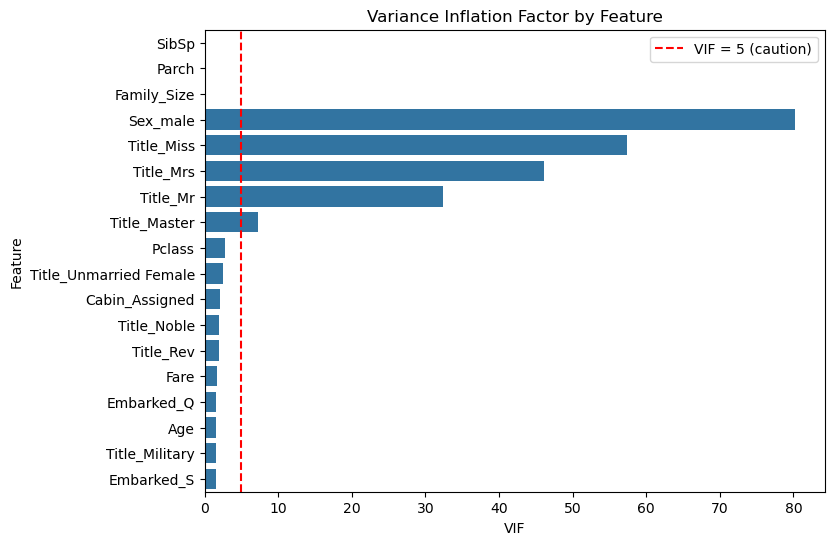

In [118]:
plt.figure(figsize=(8, 6))
sns.barplot(data=vif_data, x='VIF', y='Feature')
plt.axvline(5, color='red', linestyle='--', label='VIF = 5 (caution)')
plt.legend()
plt.title('Variance Inflation Factor by Feature')
plt.show()

## 10. Refine Features Based on VIF

Two redundancies stood out:
- `SibSp`, `Parch`, and `Family_Size` are **perfectly** collinear by construction (`Family_Size = SibSp + Parch + 1`), which produced infinite VIF.
- `Sex_male` overlaps heavily with `Title` (VIF ~80) — but `Title` carries more information (e.g. `Master` vs `Mr` splits survival rates far apart despite both being male), so we keep `Title` and drop `Sex_male`.

We drop `SibSp`, `Parch`, and `Sex_male` from everything going forward — `X_train`, `X_valid`, and both full dataframes, so `test_df` stays consistent for eventual submission predictions.

In [119]:
cols_to_drop = ['SibSp', 'Parch', 'Sex_male']

X = X.drop(columns=cols_to_drop)
X_train = X_train.drop(columns=cols_to_drop)
X_valid = X_valid.drop(columns=cols_to_drop)
train_df = train_df.drop(columns=cols_to_drop)
test_df = test_df.drop(columns=cols_to_drop)

print("Remaining features:", list(X_train.columns))

Remaining features: ['Pclass', 'Age', 'Fare', 'Family_Size', 'Cabin_Assigned', 'Embarked_Q', 'Embarked_S', 'Title_Master', 'Title_Military', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Noble', 'Title_Rev', 'Title_Unmarried Female']


### 10a. Re-check VIF after refinement

The infinite and very high VIFs should be gone. `Title_Mr`/`Title_Miss`/`Title_Mrs` will likely still show elevated VIF against each other — that's an expected structural artifact of one-hot encoding mutually-exclusive categories from the same original column, not a fixable redundancy, so it's left as-is.

In [120]:
X_vif_refined = add_constant(X_train).astype(float)

vif_refined = pd.DataFrame()
vif_refined['Feature'] = X_vif_refined.columns
vif_refined['VIF'] = [variance_inflation_factor(X_vif_refined.values, i) for i in range(X_vif_refined.shape[1])]

vif_refined = vif_refined[vif_refined['Feature'] != 'const'].sort_values('VIF', ascending=False)
vif_refined

,Feature,VIF
11,Title_Mr,29.809190
10,Title_Miss,19.759336
12,Title_Mrs,15.814053
8,Title_Master,6.837964
1,Pclass,2.794916
5,Cabin_Assigned,2.093903
14,Title_Rev,1.836141
13,Title_Noble,1.828002
3,Fare,1.631903
6,Embarked_Q,1.597520


## 11. Baseline Model — Logistic Regression

This is our benchmark: trained on the cleaned, encoded, VIF-refined data as-is, with no outlier removal and no hyperparameter tuning. Everything after this gets compared back against this number.

### 11a. Fit Logistic Regression

In [121]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_valid)

### 11b. Evaluate Baseline Performance

In [122]:
print("Accuracy:", accuracy_score(y_valid, y_pred))
print()
print(classification_report(y_valid, y_pred))

Accuracy: 0.8314606741573034

              precision    recall  f1-score   support

         0.0       0.87      0.85      0.86       110
         1.0       0.77      0.79      0.78        68

    accuracy                           0.83       178
   macro avg       0.82      0.82      0.82       178
weighted avg       0.83      0.83      0.83       178



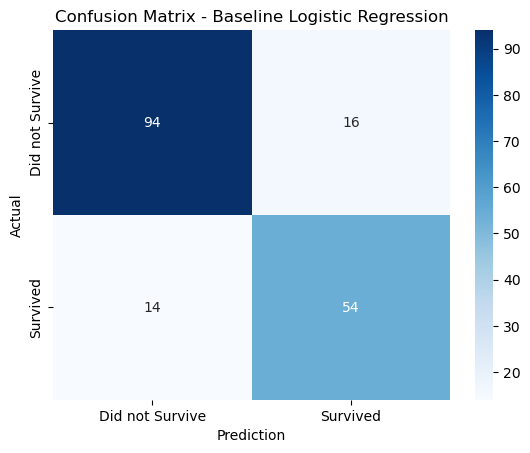

In [123]:
cm = confusion_matrix(y_valid, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Did not Survive', 'Survived'],
            yticklabels=['Did not Survive', 'Survived'])
plt.xlabel('Prediction')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Baseline Logistic Regression')
plt.show()

## 12. Testing Outlier Removal (Fare)

Following the rule from before: outliers get removed only from the data the model **learns** from (`X_train`/`y_train`). `X_valid` stays untouched, since it's standing in for real-world data the model will eventually have to predict on — including genuinely expensive fares.

### 12a. Remove Fare outliers from training data only

In [124]:
q1, q3 = X_train['Fare'].quantile(0.25), X_train['Fare'].quantile(0.75)
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr

mask = (X_train['Fare'] >= lower) & (X_train['Fare'] <= upper)

X_train_no_outliers = X_train[mask]
y_train_no_outliers = y_train[mask]

print(f"Removed {(~mask).sum()} rows from training data ({X_train.shape[0]} -> {X_train_no_outliers.shape[0]})")

Removed 90 rows from training data (711 -> 621)


### 12b. Retrain and Compare

In [125]:
log_reg_no_outliers = LogisticRegression(max_iter=1000)
log_reg_no_outliers.fit(X_train_no_outliers, y_train_no_outliers)
y_pred_no_outliers = log_reg_no_outliers.predict(X_valid)

print("Baseline accuracy (with outliers):", accuracy_score(y_valid, y_pred))
print("No-outliers accuracy:", accuracy_score(y_valid, y_pred_no_outliers))
print()
print(classification_report(y_valid, y_pred_no_outliers))

Baseline accuracy (with outliers): 0.8314606741573034
No-outliers accuracy: 0.8146067415730337

              precision    recall  f1-score   support

         0.0       0.89      0.80      0.84       110
         1.0       0.72      0.84      0.78        68

    accuracy                           0.81       178
   macro avg       0.81      0.82      0.81       178
weighted avg       0.82      0.81      0.82       178



**Decision:** accuracy came back slightly *worse* after removing outliers, at the cost of throwing away ~13% of the training data. Fare's skew carries real signal (tied to class and survival), not noise — so we keep the outliers and move forward with the original `X_train`/`y_train`.

## 13. Random Forest

Trained on the same refined `X_train`/`y_train` (outliers kept), so this compares fairly against the Logistic Regression baseline.

### 13a. Fit Random Forest

In [126]:
rf = RandomForestClassifier(random_state=21)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_valid)

### 13b. Evaluate and Compare to Logistic Regression

In [127]:
print("Logistic Regression accuracy:", accuracy_score(y_valid, y_pred))
print("Random Forest accuracy:", accuracy_score(y_valid, y_pred_rf))
print()
print("Classification report (Random Forest):")
print(classification_report(y_valid, y_pred_rf))

Logistic Regression accuracy: 0.8314606741573034
Random Forest accuracy: 0.797752808988764

Classification report (Random Forest):
              precision    recall  f1-score   support

         0.0       0.84      0.84      0.84       110
         1.0       0.74      0.74      0.74        68

    accuracy                           0.80       178
   macro avg       0.79      0.79      0.79       178
weighted avg       0.80      0.80      0.80       178



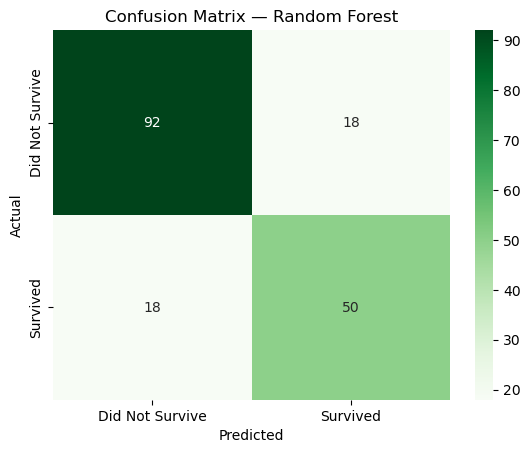

In [128]:
cm_rf = confusion_matrix(y_valid, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Did Not Survive', 'Survived'],
            yticklabels=['Did Not Survive', 'Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Random Forest')
plt.show()

### 13c. Feature Importance

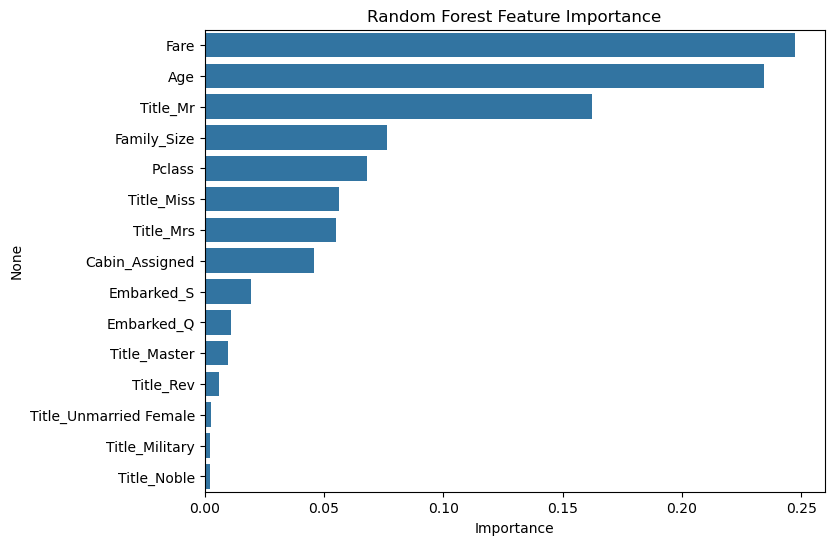

In [129]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index)
plt.xlabel('Importance')
plt.title('Random Forest Feature Importance')
plt.show()

## 14. XGBoost

A gradient-boosted tree model — same refined features, same train/validation split, so it's directly comparable to both models above.

In [130]:
xgb = XGBClassifier(random_state=21, eval_metric='logloss')
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_valid)

### 14b. Evaluate and Compare

In [131]:
print("Logistic Regression accuracy:", accuracy_score(y_valid, y_pred))
print("Random Forest accuracy:", accuracy_score(y_valid, y_pred_rf))
print("XGBoost accuracy:", accuracy_score(y_valid, y_pred_xgb))
print()
print(classification_report(y_valid, y_pred_xgb))

Logistic Regression accuracy: 0.8314606741573034
Random Forest accuracy: 0.797752808988764
XGBoost accuracy: 0.7921348314606742

              precision    recall  f1-score   support

         0.0       0.85      0.81      0.83       110
         1.0       0.71      0.76      0.74        68

    accuracy                           0.79       178
   macro avg       0.78      0.79      0.78       178
weighted avg       0.80      0.79      0.79       178



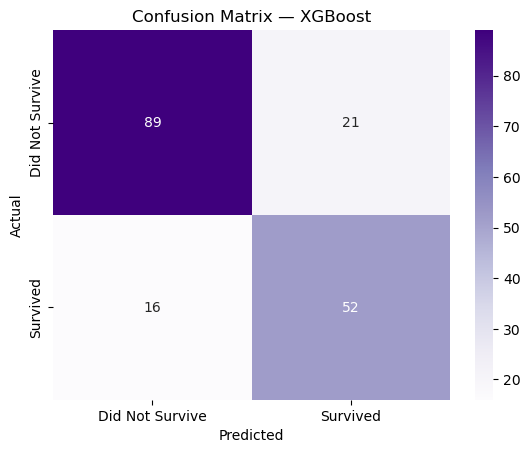

In [132]:
cm_xgb = confusion_matrix(y_valid, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Did Not Survive', 'Survived'],
            yticklabels=['Did Not Survive', 'Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — XGBoost')
plt.show()

### 14c. Feature Importance

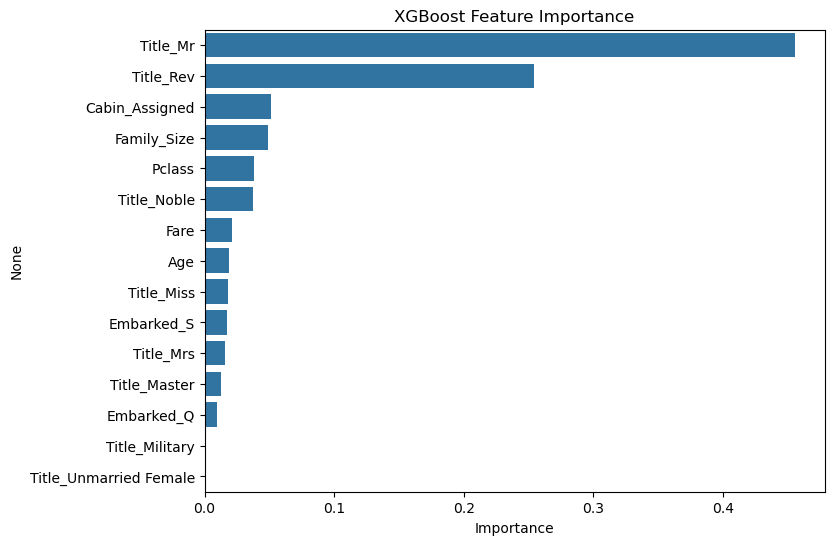

In [133]:
xgb_importances = pd.Series(xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=xgb_importances.values, y=xgb_importances.index)
plt.xlabel('Importance')
plt.title('XGBoost Feature Importance')
plt.show()

## 15. Model Comparison Summary

All three models, side by side, on the same validation set and the same refined feature set — the fairest possible comparison given everything tested above.

In [134]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_valid, y_pred),
        accuracy_score(y_valid, y_pred_rf),
        accuracy_score(y_valid, y_pred_xgb),
    ]
}).sort_values('Accuracy', ascending=False)

results

,Model,Accuracy
0,Logistic Regression,0.831461
1,Random Forest,0.797753
2,XGBoost,0.792135


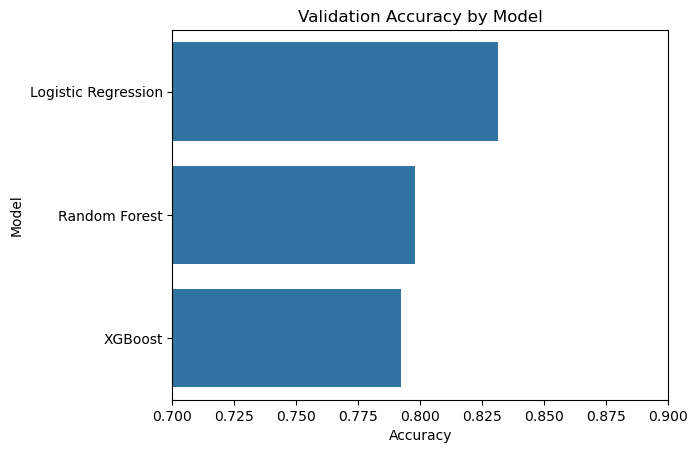

In [135]:
sns.barplot(data=results, x='Accuracy', y='Model')
plt.xlim(0.7, 0.9)
plt.title('Validation Accuracy by Model')
plt.show()

## 16. Feature Scaling (for distance-based models)

SVM and KNN measure how "close" data points are to each other, so columns on bigger raw scales (`Age`, `Fare`) can dominate that distance calculation over the 0/1 dummy columns, regardless of which is actually more predictive. Logistic Regression, Random Forest, XGBoost, and Gradient Boosting don't have this problem (trees split one feature at a time; Logistic Regression already converges fine here), so they keep using the original unscaled `X_train`/`X_valid`.

As always: the scaler is **fit on `X_train` only**, then applied to both `X_train` and `X_valid` — same train-only discipline as every imputation step earlier in this notebook.

In [136]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index
)
X_valid_scaled = pd.DataFrame(
    scaler.transform(X_valid), columns=X_valid.columns, index=X_valid.index
)

## 17. Cross-Validation — All Models

5-fold cross-validation on `X_train`/`y_train`, giving a mean accuracy plus spread (std) for every model — a more trustworthy comparison than any single 80/20 split. SVM and KNN use the scaled features; everything else uses the original.

In [137]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=21)

cv_models = {
    'Logistic Regression': (LogisticRegression(max_iter=1000), X_train, y_train),
    'Random Forest': (RandomForestClassifier(random_state=21), X_train, y_train),
    'XGBoost': (XGBClassifier(random_state=21, eval_metric='logloss'), X_train, y_train),
    'Gradient Boosting': (GradientBoostingClassifier(random_state=21), X_train, y_train),
    'SVM': (SVC(probability=True, random_state=21), X_train_scaled, y_train),
    'KNN': (KNeighborsClassifier(), X_train_scaled, y_train),
}

cv_results = []
for name, (model, X_data, y_data) in cv_models.items():
    scores = cross_val_score(model, X_data, y_data, cv=cv, scoring='accuracy')
    cv_results.append({'Model': name, 'CV Mean Accuracy': scores.mean(), 'CV Std': scores.std()})
    print(f"{name}: {scores.mean():.4f} +/- {scores.std():.4f}")

cv_results_df = pd.DataFrame(cv_results).sort_values('CV Mean Accuracy', ascending=False)
cv_results_df

Logistic Regression: 0.8215 +/- 0.0417
Random Forest: 0.8060 +/- 0.0546
XGBoost: 0.8116 +/- 0.0307
Gradient Boosting: 0.8299 +/- 0.0347
SVM: 0.8200 +/- 0.0347
KNN: 0.8200 +/- 0.0413


,Model,CV Mean Accuracy,CV Std
3,Gradient Boosting,0.829853,0.034692
0,Logistic Regression,0.821462,0.041681
4,SVM,0.820014,0.034699
5,KNN,0.819994,0.041339
2,XGBoost,0.811573,0.030699
1,Random Forest,0.805998,0.054584


## 18. Final Model Comparison

Fitting every model once on the full `X_train`/`X_valid` split (matching how each model was evaluated in cross-validation — scaled for SVM/KNN, unscaled for the rest), then comparing single-split accuracy alongside the more robust cross-validation mean.

### 18a. Fit all models

In [138]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_valid)

rf = RandomForestClassifier(random_state=21)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_valid)

xgb = XGBClassifier(random_state=21, eval_metric='logloss')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_valid)

gbc = GradientBoostingClassifier(random_state=21)
gbc.fit(X_train, y_train)
y_pred_gbc = gbc.predict(X_valid)

svc = SVC(probability=True, random_state=21)
svc.fit(X_train_scaled, y_train)
y_pred_svc = svc.predict(X_valid_scaled)

knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_valid_scaled)

### 18b. Compare validation accuracy and CV mean, side by side

In [139]:
final_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost', 'Gradient Boosting', 'SVM', 'KNN'],
    'Validation Accuracy': [
        accuracy_score(y_valid, y_pred),
        accuracy_score(y_valid, y_pred_rf),
        accuracy_score(y_valid, y_pred_xgb),
        accuracy_score(y_valid, y_pred_gbc),
        accuracy_score(y_valid, y_pred_svc),
        accuracy_score(y_valid, y_pred_knn),
    ]
})

final_results = final_results.merge(cv_results_df, on='Model', how='left')
final_results = final_results.sort_values('CV Mean Accuracy', ascending=False)
final_results

,Model,Validation Accuracy,CV Mean Accuracy,CV Std
3,Gradient Boosting,0.837079,0.829853,0.034692
0,Logistic Regression,0.831461,0.821462,0.041681
4,SVM,0.831461,0.820014,0.034699
5,KNN,0.820225,0.819994,0.041339
2,XGBoost,0.792135,0.811573,0.030699
1,Random Forest,0.797753,0.805998,0.054584


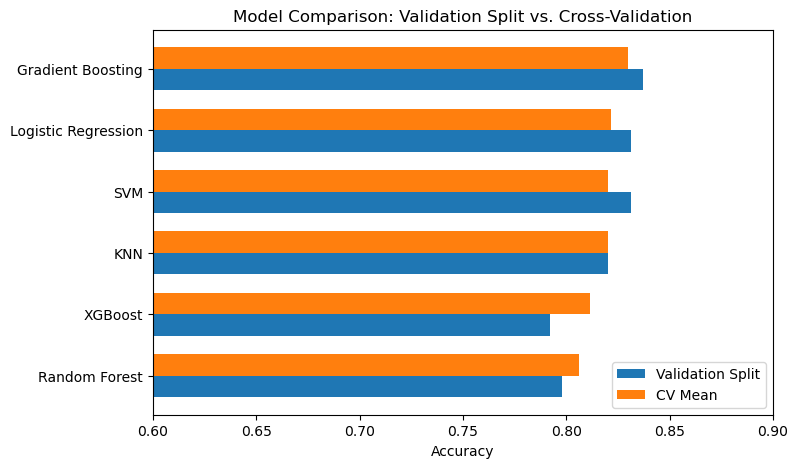

In [140]:
plt.figure(figsize=(8, 5))
x = range(len(final_results))
width = 0.35

plt.barh([i + width/2 for i in x], final_results['Validation Accuracy'], height=width, label='Validation Split')
plt.barh([i - width/2 for i in x], final_results['CV Mean Accuracy'], height=width, label='CV Mean')
plt.yticks(list(x), final_results['Model'])
plt.xlabel('Accuracy')
plt.xlim(0.6, 0.9)
plt.title('Model Comparison: Validation Split vs. Cross-Validation')
plt.legend()
plt.gca().invert_yaxis()
plt.show()

### 18c. Best-performing model on real data

Given the CV mean is the more trustworthy number (less sensitive to which passengers happened to land in the single validation split), that's the column worth trusting most for picking a "winner" to carry forward into hyperparameter tuning.

## 19. Hyperparameter Tuning

`GridSearchCV` tries every combination of hyperparameter values in a given grid, scoring each with cross-validation, and keeps whichever combination performed best. Focusing this on Random Forest, XGBoost, and Gradient Boosting — the three models that have only ever run on default settings so far, and (for RF/XGBoost) the weakest performers in the last comparison. Logistic Regression, SVM, and KNN are left as-is; they have far fewer meaningful hyperparameters and were already competitive.

### 19a. Tune Random Forest

In [141]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=21),
    param_grid_rf,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=21),
    scoring='accuracy',
    n_jobs=-1
)
grid_rf.fit(X_train, y_train)

print("Best params:", grid_rf.best_params_)
print("Best CV accuracy:", grid_rf.best_score_)

Best params: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}
Best CV accuracy: 0.8383039495715552


### 19b. Tune XGBoost

In [142]:
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
}

grid_xgb = GridSearchCV(
    XGBClassifier(random_state=21, eval_metric='logloss'),
    param_grid_xgb,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=21),
    scoring='accuracy',
    n_jobs=-1
)
grid_xgb.fit(X_train, y_train)

print("Best params:", grid_xgb.best_params_)
print("Best CV accuracy:", grid_xgb.best_score_)

Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best CV accuracy: 0.8411208509800059


### 19c. Tune Gradient Boosting

In [143]:
param_grid_gbc = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
}

grid_gbc = GridSearchCV(
    GradientBoostingClassifier(random_state=21),
    param_grid_gbc,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=21),
    scoring='accuracy',
    n_jobs=-1
)
grid_gbc.fit(X_train, y_train)

print("Best params:", grid_gbc.best_params_)
print("Best CV accuracy:", grid_gbc.best_score_)

Best params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100}
Best CV accuracy: 0.8369053481729539


### 19d. Evaluate Tuned Models on the Validation Set

`best_score_` above is a cross-validated *training* estimate. Checking against `X_valid` (never touched during tuning) confirms whether the improvement holds up on genuinely unseen data.

In [144]:
y_pred_rf_tuned = grid_rf.best_estimator_.predict(X_valid)
y_pred_xgb_tuned = grid_xgb.best_estimator_.predict(X_valid)
y_pred_gbc_tuned = grid_gbc.best_estimator_.predict(X_valid)

print("Random Forest      -- default:", accuracy_score(y_valid, y_pred_rf), " | tuned:", accuracy_score(y_valid, y_pred_rf_tuned))
print("XGBoost             -- default:", accuracy_score(y_valid, y_pred_xgb), " | tuned:", accuracy_score(y_valid, y_pred_xgb_tuned))
print("Gradient Boosting   -- default:", accuracy_score(y_valid, y_pred_gbc), " | tuned:", accuracy_score(y_valid, y_pred_gbc_tuned))

Random Forest      -- default: 0.797752808988764  | tuned: 0.8370786516853933
XGBoost             -- default: 0.7921348314606742  | tuned: 0.8202247191011236
Gradient Boosting   -- default: 0.8370786516853933  | tuned: 0.8370786516853933


### 19e. Updated Final Comparison

In [145]:
tuned_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'SVM', 'KNN',
              'Random Forest (default)', 'Random Forest (tuned)',
              'XGBoost (default)', 'XGBoost (tuned)',
              'Gradient Boosting (default)', 'Gradient Boosting (tuned)'],
    'Validation Accuracy': [
        accuracy_score(y_valid, y_pred),
        accuracy_score(y_valid, y_pred_svc),
        accuracy_score(y_valid, y_pred_knn),
        accuracy_score(y_valid, y_pred_rf),
        accuracy_score(y_valid, y_pred_rf_tuned),
        accuracy_score(y_valid, y_pred_xgb),
        accuracy_score(y_valid, y_pred_xgb_tuned),
        accuracy_score(y_valid, y_pred_gbc),
        accuracy_score(y_valid, y_pred_gbc_tuned),
    ]
}).sort_values('Validation Accuracy', ascending=False)

tuned_results

,Model,Validation Accuracy
4,Random Forest (tuned),0.837079
7,Gradient Boosting (default),0.837079
8,Gradient Boosting (tuned),0.837079
0,Logistic Regression,0.831461
1,SVM,0.831461
2,KNN,0.820225
6,XGBoost (tuned),0.820225
3,Random Forest (default),0.797753
5,XGBoost (default),0.792135


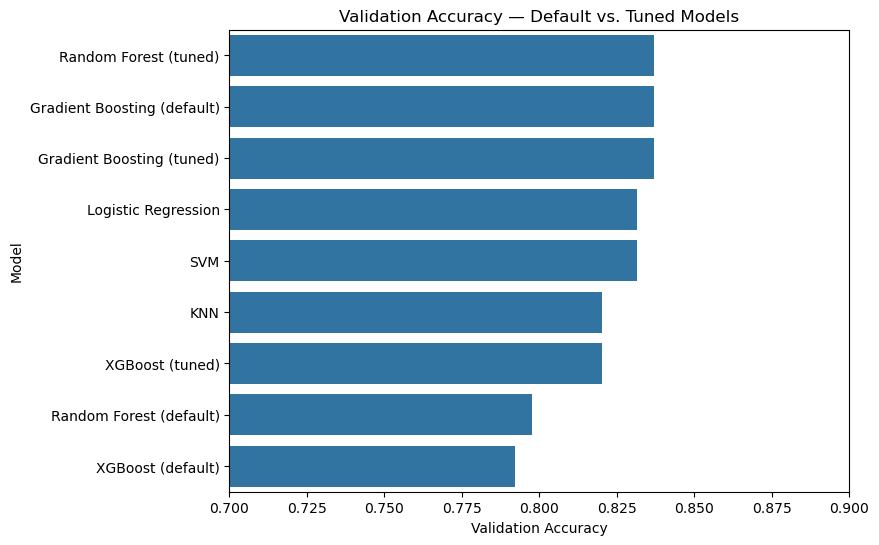

In [146]:
plt.figure(figsize=(8, 6))
sns.barplot(data=tuned_results, x='Validation Accuracy', y='Model')
plt.xlim(0.7, 0.9)
plt.title('Validation Accuracy — Default vs. Tuned Models')
plt.show()

## 20. ROC / AUC Analysis

Every metric so far (accuracy, precision, recall) is based on each model's default 0.5 probability cutoff for "predict survived." The ROC curve looks at performance *across every possible threshold* instead of just one — plotting the true positive rate against the false positive rate as that cutoff slides from 0 to 1. AUC (Area Under the Curve) condenses that into a single number: 1.0 is a perfect model, 0.5 is no better than a coin flip. It's a more complete picture than accuracy alone, especially with classes that aren't perfectly balanced, like Survived/Not Survived here.

### 20a. Get predicted probabilities for each model

In [147]:
proba_models = {
    'Logistic Regression': log_reg.predict_proba(X_valid)[:, 1],
    'Random Forest (tuned)': grid_rf.best_estimator_.predict_proba(X_valid)[:, 1],
    'XGBoost (tuned)': grid_xgb.best_estimator_.predict_proba(X_valid)[:, 1],
    'Gradient Boosting (tuned)': grid_gbc.best_estimator_.predict_proba(X_valid)[:, 1],
    'SVM': svc.predict_proba(X_valid_scaled)[:, 1],
    'KNN': knn.predict_proba(X_valid_scaled)[:, 1],
}

### 20b. Plot ROC Curves

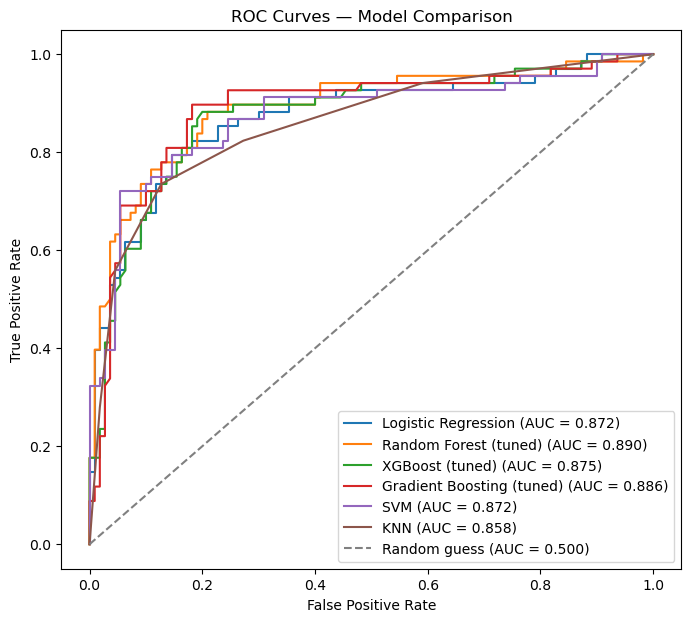

In [148]:
plt.figure(figsize=(8, 7))

for name, proba in proba_models.items():
    fpr, tpr, _ = roc_curve(y_valid, proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess (AUC = 0.500)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Model Comparison')
plt.legend(loc='lower right')
plt.show()

### 20c. AUC Summary Table

In [149]:
auc_results = []
for name, proba in proba_models.items():
    fpr, tpr, _ = roc_curve(y_valid, proba)
    auc_results.append({'Model': name, 'AUC': auc(fpr, tpr)})

auc_df = pd.DataFrame(auc_results).sort_values('AUC', ascending=False)
auc_df

,Model,AUC
1,Random Forest (tuned),0.890040
3,Gradient Boosting (tuned),0.885896
2,XGBoost (tuned),0.874866
4,SVM,0.872460
0,Logistic Regression,0.871524
5,KNN,0.858088


## 21. Generate Kaggle Submission

**Final model: Random Forest (tuned)** — best AUC (0.890), tied for best accuracy (83.7%), and the model that improved most from tuning.

For this final step we retrain on **all** available labeled data (`X` + `y`, the full `train_df`) using the best hyperparameters found in Section 19, rather than just `X_train`. The validation split has already done its job — proving the model works and picking good settings — so there's no reason to hold back 20% of real training signal any longer.

### 21a. Retrain the final model on all training data

In [150]:
final_model = RandomForestClassifier(**grid_rf.best_params_, random_state=21)
final_model.fit(X, y)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,10
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### 21b. Align test_df's columns with the training features

`test_df` needs to have exactly the same columns, in the same order, as what the model was trained on (everything except `PassengerId`, which isn't a feature — it's an identifier we need to keep for the submission file itself).

In [151]:
X_test_final = test_df[X.columns]

print("Feature columns match:", list(X_test_final.columns) == list(X.columns))
print("X_test_final shape:", X_test_final.shape)

Feature columns match: True
X_test_final shape: (418, 15)


### 21c. Predict and build the submission file

In [152]:
test_predictions = final_model.predict(X_test_final).astype(int)

submission = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Survived': test_predictions
})

print("Submission shape:", submission.shape)
submission.head()

Submission shape: (418, 2)


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


### 21d. Save to CSV

In [153]:
submission.to_csv('submission.csv', index=False)
print("Saved submission.csv")

Saved submission.csv
